# Taller B4-T1 — Diseño de Redes Confiables (Justicia e Incertidumbre)

Modelo de clasificación neuronal para **concesión de créditos** (*Home Credit Default Risk*)
que es **preciso**, **justo** (sin discriminar por género) e **incierto-consciente**.

Predecimos `TARGET` (1 = impago / "mal pagador", 0 = paga). Variable **sensible**: `CODE_GENDER`.

**Las 4 tareas:**
1. **Capa customizada** — `DebtRatioSaturationLayer`: calcula el ratio de endeudamiento y lo satura.
2. **FAIR loss** — `BCE + λ·corr(ŷ, género)²`.
3. **AutoML** — `keras_tuner` + curva de Pareto Precisión vs Dependencia.
4. **Incertidumbre** — MC-Dropout (varianza de la predicción).

> Pensado para **Google Colab** (TensorFlow + Keras 3). En local necesitas Python 3.11/3.12
> con TensorFlow (TF no soporta 3.14). Ajusta `CSV_PATH` en la celda de configuración.

## 0. Configuración y librerías

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import keras
from keras import layers, ops
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score

# --- Ruta al CSV de Home Credit (application_train.csv) ---
_cand = ["data/application_train.csv",
         os.path.expanduser("~/TallerB4-T1/data/application_train.csv"),
         "application_train.csv",
         "/content/application_train.csv",
         os.path.expanduser("~/Downloads/application_train.csv")]
CSV_PATH = next((p for p in _cand if os.path.exists(p)), _cand[0])

SEED = 42
SUBSAMPLE = 40000   # nº de filas para iterar rápido; pon None para usar TODO (resultado final)
EPOCHS = 25
BATCH = 256
os.makedirs("outputs", exist_ok=True)

keras.utils.set_random_seed(SEED); np.random.seed(SEED)
print("Keras:", keras.__version__, "| backend:", keras.config.backend())
print("CSV_PATH =", CSV_PATH, "| existe:", os.path.exists(CSV_PATH))

Keras: 3.14.1 | backend: tensorflow
CSV_PATH = data/application_train.csv | existe: True


## 1. Carga y preprocesado de datos

Loader basado en el del esqueleto del taller, con tres mejoras:
- **Guarda el nº de `EXT_SOURCE` ausentes por persona ANTES de imputar** (proxy de calidad → incertidumbre).
- **Imputa también `AMT_ANNUITY`** (el loader original dejaba 12 NaN → rompía el entrenamiento).
- **Medianas y escalado ajustados sólo en TRAIN** (sin fuga de información) y split **estratificado** por el desbalanceo.

`X` final = `[8 features escaladas | 3 financieras crudas positivas]`. Las 3 crudas las usa la
capa customizada para calcular ratios (necesitan ser positivas).

In [2]:
BASE_FEATURES = ['CODE_GENDER','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',
                 'AGE_YEARS','EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
RAW_FIN  = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY']     # positivos -> ratios en la capa custom
EXT_COLS = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']

def load_home_credit(path, subsample=None, seed=SEED):
    cols = ['TARGET','CODE_GENDER','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','DAYS_BIRTH'] + EXT_COLS
    df = pd.read_csv(path, usecols=cols)
    if subsample:
        df = df.sample(n=min(subsample, len(df)), random_state=seed).reset_index(drop=True)

    # nº de EXT_SOURCE ausentes ANTES de imputar (clave para la incertidumbre)
    n_missing_ext = df[EXT_COLS].isna().sum(axis=1).values.astype('int32')

    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M':0,'F':1}).fillna(0).astype('float32')  # sensible
    df['AGE_YEARS']   = df['DAYS_BIRTH'].abs() / 365.0

    y = df['TARGET'].astype('float32').values
    s = df['CODE_GENDER'].astype('float32').values

    idx = np.arange(len(df))
    tr, te = train_test_split(idx, test_size=0.2, random_state=seed, stratify=y)

    feat = df[BASE_FEATURES].astype('float32')
    raw  = df[RAW_FIN].astype('float32')
    feat = feat.fillna(feat.iloc[tr].median())      # imputa medianas de TRAIN (incl. AMT_ANNUITY)
    raw  = raw.fillna(raw.iloc[tr].median())

    scaler = StandardScaler().fit(feat.iloc[tr].values)
    Xb   = scaler.transform(feat.values).astype('float32')   # features escaladas
    Xraw = raw.values.astype('float32')                      # positivas, sin escalar
    X = np.hstack([Xb, Xraw]).astype('float32')              # [8 | 3] = 11 columnas

    return dict(X_train=X[tr], X_test=X[te], y_train=y[tr], y_test=y[te],
                s_train=s[tr], s_test=s[te], nmiss_train=n_missing_ext[tr],
                nmiss_test=n_missing_ext[te], n_base=len(BASE_FEATURES))

data = load_home_credit(CSV_PATH, subsample=SUBSAMPLE)
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']
s_train, s_test = data['s_train'], data['s_test']
N_BASE = data['n_base']
print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| n_base:", N_BASE)

pos = y_train.mean()
cw = {0: 1.0, 1: float((1 - pos) / pos)}     # class_weight para el desbalanceo
print(f"Impagos en train: {pos:.3%} | class_weight = {{0:1.0, 1:{cw[1]:.2f}}}")

X_train: (32000, 11) | X_test: (8000, 11) | n_base: 8
Impagos en train: 8.106% | class_weight = {0:1.0, 1:11.34}


## 2. Análisis exploratorio

Tres gráficas que motivan el diseño: (a) el género está correlado con el impago → justicia;
(b) los ingresos tienen cola muy pesada → motiva la saturación de la capa custom;
(c) a peor calidad de `EXT_SOURCE` (más ausentes) mayor impago → motiva medir incertidumbre.

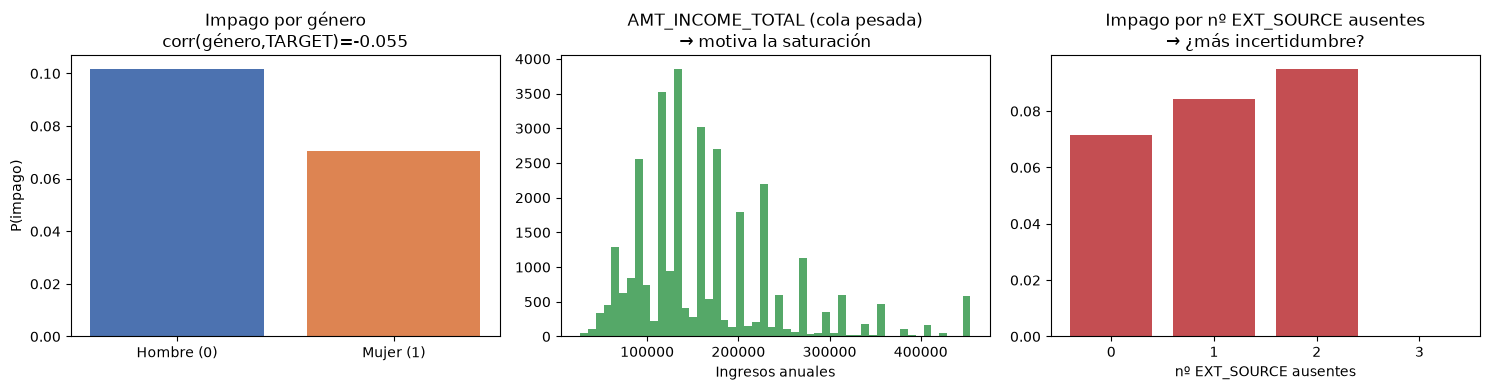

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

g = pd.DataFrame({'g': s_train, 'y': y_train}).groupby('g')['y'].mean()
ax[0].bar(['Hombre (0)', 'Mujer (1)'], g.values, color=['#4C72B0', '#DD8452'])
ax[0].set_title(f"Impago por género\ncorr(género,TARGET)={np.corrcoef(s_train,y_train)[0,1]:.3f}")
ax[0].set_ylabel("P(impago)")

inc = X_train[:, N_BASE + 0]   # AMT_INCOME_TOTAL crudo
ax[1].hist(np.clip(inc, 0, np.percentile(inc, 99)), bins=50, color='#55A868')
ax[1].set_title("AMT_INCOME_TOTAL (cola pesada)\n→ motiva la saturación")
ax[1].set_xlabel("Ingresos anuales")

d = pd.DataFrame({'nm': data['nmiss_train'], 'y': y_train}).groupby('nm')['y'].mean()
ax[2].bar(d.index.astype(str), d.values, color='#C44E52')
ax[2].set_title("Impago por nº EXT_SOURCE ausentes\n→ ¿más incertidumbre?")
ax[2].set_xlabel("nº EXT_SOURCE ausentes")
plt.tight_layout(); plt.show()

## 3. Tarea 1 — Capa customizada: `DebtRatioSaturationLayer`

Capa Keras escrita **solo con `keras.ops`** (backend-agnóstica). Recibe el vector
`[8 features escaladas | income, credit, annuity crudos]` y:

1. **Calcula internamente los ratios de endeudamiento**: `crédito/ingresos`,
   `anualidad/ingresos` (ratio de endeudamiento) y `anualidad/crédito` (división segura con ε).
2. **Restricción matemática (saturación):** aplica `ratio**p` con **exponentes `p∈[0.1,1]`
   entrenables** (constraint de clip). Con `p<1` comprime las colas pesadas.
3. Devuelve `[features base | ratios saturados]` para las capas densas.

In [4]:
class ClipConstraint(keras.constraints.Constraint):
    """Mantiene un peso dentro de [lo, hi]."""
    def __init__(self, lo, hi): self.lo, self.hi = lo, hi
    def __call__(self, w): return keras.ops.clip(w, self.lo, self.hi)
    def get_config(self): return {"lo": self.lo, "hi": self.hi}

class DebtRatioSaturationLayer(keras.layers.Layer):
    """Calcula ratios financieros y les aplica una saturación x**p (p entrenable, clip [0.1,1])."""
    def __init__(self, n_base, eps=1e-6, **kw):
        super().__init__(**kw); self.n_base = n_base; self.eps = eps
    def build(self, input_shape):
        # 3 ratios -> 3 exponentes de saturación, init 0.5 (comprime colas)
        self.p = self.add_weight(shape=(3,), name="sat_exponent",
                                 initializer=keras.initializers.Constant(0.5),
                                 constraint=ClipConstraint(0.1, 1.0), trainable=True)
        super().build(input_shape)
    def call(self, x):
        base    = x[:, :self.n_base]
        income  = x[:, self.n_base:self.n_base + 1]
        credit  = x[:, self.n_base + 1:self.n_base + 2]
        annuity = x[:, self.n_base + 2:self.n_base + 3]
        credit_income  = credit  / (income + self.eps)   # apalancamiento
        annuity_income = annuity / (income + self.eps)   # ratio de endeudamiento
        annuity_credit = annuity / (credit + self.eps)   # ~ inversa del plazo
        ratios = keras.ops.concatenate([credit_income, annuity_income, annuity_credit], axis=-1)
        ratios = keras.ops.maximum(ratios, 0.0)          # positivos -> power seguro
        sat = keras.ops.power(ratios + self.eps, self.p) # saturación entrenable
        return keras.ops.concatenate([base, sat], axis=-1)
    def compute_output_shape(self, ishape):
        return (ishape[0], self.n_base + 3)
    def get_config(self):
        c = super().get_config(); c.update({"n_base": self.n_base, "eps": self.eps}); return c

print("Capa custom definida. Salida =", N_BASE, "features base + 3 ratios saturados =", N_BASE + 3)

Capa custom definida. Salida = 8 features base + 3 ratios saturados = 11


## 4. Tarea 2 — FAIR loss + helpers de modelo y evaluación

`CustomFairnessLoss = BCE_ponderada(y, ŷ) + λ · corr(ŷ, género)²`. La métrica de dependencia
es la **correlación de Pearson** (diferenciable) entre la probabilidad predicha y el género;
al cuadrado para empujarla a 0. El sensible se pasa concatenado en `y_true` (2 columnas
`[TARGET, género]`). La BCE va ponderada por `pos_weight` para tratar el desbalanceo dentro
de la propia loss (así no necesitamos `class_weight`, incompatible con `y_true` de 2 columnas).

In [5]:
class CustomFairnessLoss(keras.losses.Loss):
    def __init__(self, lambda_corr=0.5, pos_weight=1.0, name="fair_loss", **kw):
        super().__init__(name=name, **kw)
        self.lambda_corr = lambda_corr; self.pos_weight = pos_weight
    def call(self, y_true_ext, y_pred):
        eps = 1e-7
        yt = keras.ops.reshape(y_true_ext[:, 0], (-1,))            # TARGET
        s  = keras.ops.reshape(y_true_ext[:, 1], (-1,))            # variable sensible
        yp = keras.ops.clip(keras.ops.reshape(y_pred, (-1,)), eps, 1.0 - eps)
        # BCE ponderada por clase (solo keras.ops)
        bce_vec = keras.ops.binary_crossentropy(yt, yp)
        w   = 1.0 + (self.pos_weight - 1.0) * yt
        bce = keras.ops.sum(w * bce_vec) / (keras.ops.sum(w) + eps)
        # correlación de Pearson(ŷ, s) diferenciable (solo keras.ops)
        cov = keras.ops.mean((yp - keras.ops.mean(yp)) * (s - keras.ops.mean(s)))
        denom = keras.ops.std(yp) * keras.ops.std(s) + eps
        corr = cov / denom
        return bce + self.lambda_corr * keras.ops.square(corr)
    def get_config(self):
        c = super().get_config()
        c.update({"lambda_corr": self.lambda_corr, "pos_weight": self.pos_weight}); return c

def extend_y(y, s):
    return np.stack([y.astype('float32'), s.astype('float32')], axis=1)

def build_model(lambda_corr, n_features, n_base, hidden=(64, 32), dropout=0.2,
                activation='relu', lr=1e-3, pos_weight=1.0):
    """MLP con capa custom + dropout (necesario para MC-Dropout). λ=0 => modelo base."""
    inp = keras.Input(shape=(n_features,))
    x = DebtRatioSaturationLayer(n_base=n_base)(inp)
    x = layers.BatchNormalization()(x)
    for h in hidden:
        x = layers.Dense(h, activation=activation)(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss=CustomFairnessLoss(lambda_corr=lambda_corr, pos_weight=pos_weight))
    return model

def dependence(y_pred, s, thr=0.5):
    yp = np.asarray(y_pred).flatten(); s = np.asarray(s).flatten()
    corr = abs(np.corrcoef(yp, s)[0, 1])
    yhat = (yp >= thr).astype(int)
    dp = abs(yhat[s == 1].mean() - yhat[s == 0].mean())   # demographic parity gap
    return corr, dp

def evaluate(model, X, y, s):
    yp = model.predict(X, verbose=0).flatten()
    corr, dp = dependence(yp, s)
    try: auc = roc_auc_score(y, yp)
    except ValueError: auc = float('nan')
    return dict(accuracy=accuracy_score(y, (yp >= 0.5).astype(int)), auc=auc,
                dependence_corr=corr, dp_gap=dp)

## 5. Tarea 3 — AutoML con Keras Tuner

Búsqueda de la topología óptima (nº de capas, unidades, activación, dropout, learning rate)
con `RandomSearch`, optimizando el **AUC de validación** (mejor que accuracy con desbalanceo).

In [6]:
import keras_tuner as kt

def build_tuned(hp):
    n_layers = hp.Int('n_layers', 1, 3)
    units    = hp.Choice('units', [32, 64, 128])
    act      = hp.Choice('activation', ['relu', 'tanh'])
    drop     = hp.Float('dropout', 0.0, 0.4, step=0.1)
    lr       = hp.Float('lr', 1e-4, 5e-3, sampling='log')
    inp = keras.Input(shape=(X_train.shape[1],))
    x = DebtRatioSaturationLayer(n_base=N_BASE)(inp)
    x = layers.BatchNormalization()(x)
    for _ in range(n_layers):
        x = layers.Dense(units, activation=act)(x)
        x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy',
              metrics=[keras.metrics.AUC(name='auc')])
    return m

MAX_TRIALS = 8
tuner = kt.RandomSearch(build_tuned, objective=kt.Objective('val_auc', 'max'),
                        max_trials=MAX_TRIALS, overwrite=True,
                        directory='keras_tuner_dir', project_name='fair_credit', seed=SEED)
tuner.search(X_train, y_train, validation_split=0.15, epochs=12, batch_size=BATCH,
             class_weight=cw, verbose=0)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejor arquitectura:", best_hp.values)

Mejor arquitectura: {'n_layers': 2, 'units': 32, 'activation': 'relu', 'dropout': 0.1, 'lr': 0.0032295411136862955}


## 6. Modelo Base + barrido de λ → Curva de Pareto

Con la arquitectura encontrada entrenamos el mismo modelo para varios `λ` (λ=0 es el **Base**,
sin restricción de justicia). Para cada uno medimos en *test* precisión, AUC y dependencia.

In [7]:
best_hidden = tuple([best_hp.get('units')] * best_hp.get('n_layers'))
best_act = best_hp.get('activation')
best_drop = max(best_hp.get('dropout'), 0.1)   # dropout>0 para poder hacer MC-Dropout
best_lr = best_hp.get('lr')

yext_tr = extend_y(y_train, s_train)
LAMBDAS = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
pareto, fair_models, histories = [], {}, {}
for lam in LAMBDAS:
    m = build_model(lam, X_train.shape[1], N_BASE, hidden=best_hidden, dropout=best_drop,
                    activation=best_act, lr=best_lr, pos_weight=cw[1])
    h = m.fit(X_train, yext_tr, validation_split=0.15, epochs=EPOCHS, batch_size=BATCH, verbose=0)
    met = evaluate(m, X_test, y_test, s_test); met['lambda'] = lam
    pareto.append(met); fair_models[lam] = m; histories[lam] = h
    print(f"λ={lam:>4}: acc={met['accuracy']:.4f}  auc={met['auc']:.4f}  "
          f"|corr|={met['dependence_corr']:.4f}  dp_gap={met['dp_gap']:.4f}")
pareto_df = pd.DataFrame(pareto)

λ= 0.0: acc=0.6960  auc=0.7251  |corr|=0.3028  dp_gap=0.2398


λ=0.25: acc=0.7137  auc=0.7207  |corr|=0.0958  dp_gap=0.0572


λ= 0.5: acc=0.7143  auc=0.7169  |corr|=0.0610  dp_gap=0.0301


λ= 1.0: acc=0.7249  auc=0.7190  |corr|=0.0640  dp_gap=0.0333


λ= 2.0: acc=0.7185  auc=0.7174  |corr|=0.0357  dp_gap=0.0020


λ= 4.0: acc=0.7107  auc=0.7103  |corr|=0.0034  dp_gap=0.0516


λ= 8.0: acc=0.7183  auc=0.7140  |corr|=0.0291  dp_gap=0.0259


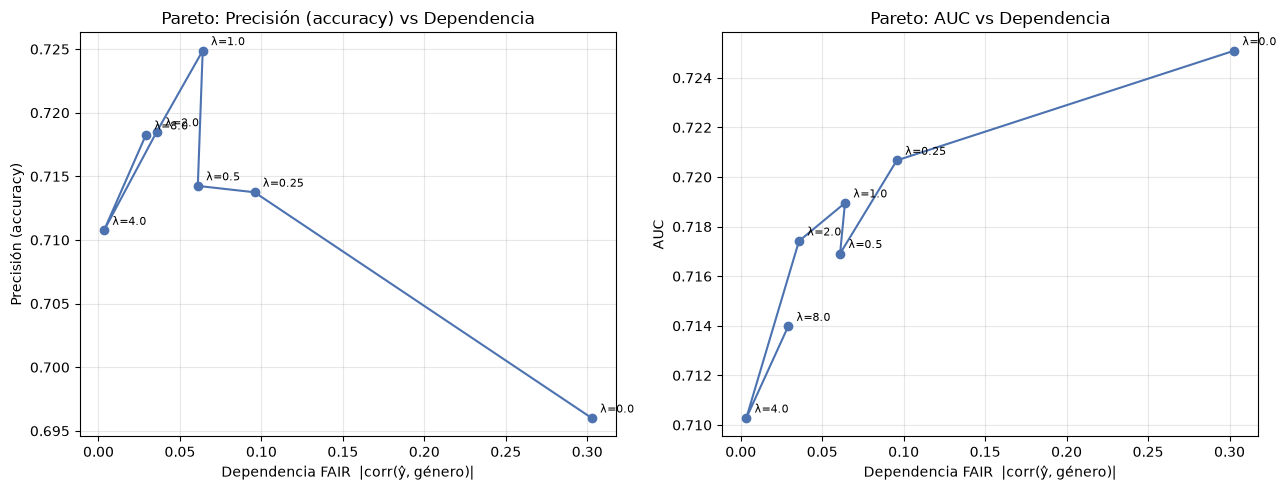

In [8]:
# Curva de Pareto: Precisión (eje Y, como pide el enunciado) y AUC vs Dependencia FAIR (eje X)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for axi, ycol, ylab in [(ax[0], 'accuracy', 'Precisión (accuracy)'), (ax[1], 'auc', 'AUC')]:
    axi.plot(pareto_df['dependence_corr'], pareto_df[ycol], 'o-', color='#4C72B0')
    for _, r in pareto_df.iterrows():
        axi.annotate(f"λ={r['lambda']}", (r['dependence_corr'], r[ycol]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)
    axi.set_xlabel("Dependencia FAIR  |corr(ŷ, género)|"); axi.set_ylabel(ylab)
    axi.set_title(f"Pareto: {ylab} vs Dependencia"); axi.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("outputs/pareto.png", dpi=120, bbox_inches='tight'); plt.show()

In [9]:
# Selección del mejor modelo FAIR: menor dependencia manteniendo AUC >= 98% del base
base_row = pareto_df[pareto_df['lambda'] == 0.0].iloc[0]
cand = pareto_df[pareto_df['lambda'] > 0].copy()
keep = cand[cand['auc'] >= 0.98 * base_row['auc']]
best_fair_row = (keep if len(keep) else cand).sort_values('dependence_corr').iloc[0]
BEST_LAMBDA = best_fair_row['lambda']
best_fair_model = fair_models[BEST_LAMBDA]

print("BASE  (λ=0):", {k: round(base_row[k], 4) for k in ['accuracy','auc','dependence_corr','dp_gap']})
print(f"FAIR  (λ={BEST_LAMBDA}):", {k: round(best_fair_row[k], 4) for k in ['accuracy','auc','dependence_corr','dp_gap']})

sat = [l for l in best_fair_model.layers if isinstance(l, DebtRatioSaturationLayer)][0]
print("Exponentes de saturación aprendidos (p):", np.round(keras.ops.convert_to_numpy(sat.p), 3))

BASE  (λ=0): {'accuracy': np.float64(0.696), 'auc': np.float64(0.7251), 'dependence_corr': np.float64(0.3028), 'dp_gap': np.float64(0.2398)}
FAIR  (λ=8.0): {'accuracy': np.float64(0.7183), 'auc': np.float64(0.714), 'dependence_corr': np.float64(0.0291), 'dp_gap': np.float64(0.0259)}
Exponentes de saturación aprendidos (p): [0.109 0.716 0.43 ]


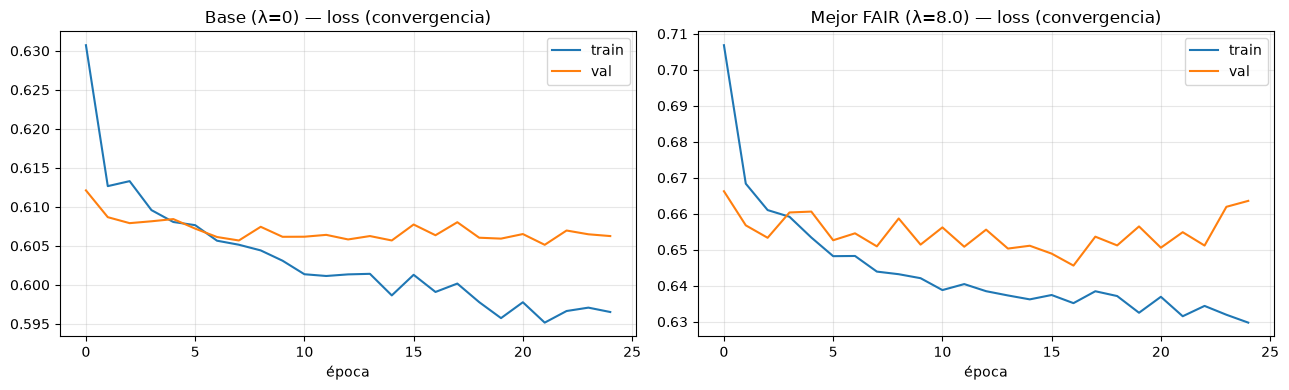

In [10]:
# Curvas de loss (convergencia) de los dos entrenamientos finales: Base y mejor FAIR
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for axi, lam, title in [(ax[0], 0.0, "Base (λ=0)"), (ax[1], BEST_LAMBDA, f"Mejor FAIR (λ={BEST_LAMBDA})")]:
    h = histories[lam]
    axi.plot(h.history['loss'], label='train')
    axi.plot(h.history['val_loss'], label='val')
    axi.set_title(f"{title} — loss (convergencia)"); axi.set_xlabel("época"); axi.legend(); axi.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("outputs/loss_curves.png", dpi=120, bbox_inches='tight'); plt.show()

## 7. Tarea 4 — Incertidumbre con MC-Dropout

Dejamos el **dropout activo en inferencia** (`training=True`) y hacemos `T` pasadas
estocásticas: la **media** es la predicción y la **varianza** es la incertidumbre. Después
comprobamos si la incertidumbre es mayor en perfiles con peores fuentes externas.

In [11]:
def mc_dropout_predict(model, X, T=50, batch=4096):
    preds = np.zeros((T, X.shape[0]), dtype='float32')
    for t in range(T):
        out = []
        for i in range(0, X.shape[0], batch):
            xb = keras.ops.convert_to_tensor(X[i:i+batch])
            out.append(keras.ops.convert_to_numpy(model(xb, training=True)).flatten())
        preds[t] = np.concatenate(out)
    return preds.mean(0), preds.var(0)

T_MC = 50
mean_pred, var_pred = mc_dropout_predict(best_fair_model, X_test, T=T_MC)
yhat_test = (mean_pred >= 0.5).astype(int)
print(f"Varianza media de la predicción: {var_pred.mean():.5f}")

Varianza media de la predicción: 0.00197


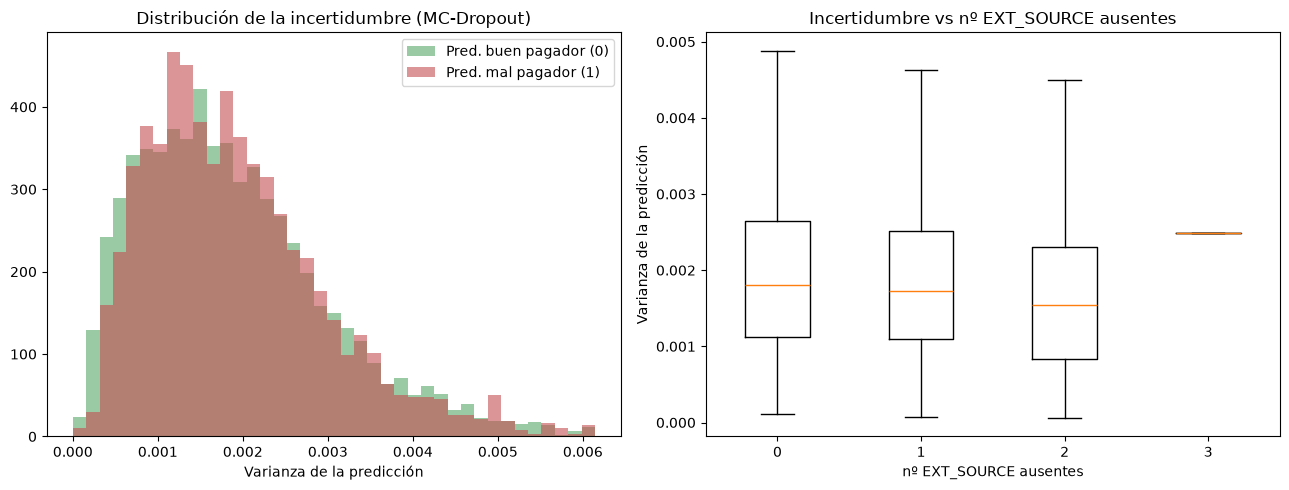

Varianza media por nº de EXT_SOURCE ausentes:
  0 ausentes -> var media = 0.00204  (n=2901)
  1 ausentes -> var media = 0.00197  (n=4146)
  2 ausentes -> var media = 0.00171  (n=952)
  3 ausentes -> var media = 0.00248  (n=1)


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (a) distribución de la incertidumbre: predicho buen pagador (0) vs mal pagador (1)
v_good, v_bad = var_pred[yhat_test == 0], var_pred[yhat_test == 1]
bins = np.linspace(0, np.percentile(var_pred, 99) + 1e-9, 40)
ax[0].hist(v_good, bins=bins, alpha=0.6, density=True, color='#55A868', label='Pred. buen pagador (0)')
ax[0].hist(v_bad,  bins=bins, alpha=0.6, density=True, color='#C44E52', label='Pred. mal pagador (1)')
ax[0].set_title("Distribución de la incertidumbre (MC-Dropout)")
ax[0].set_xlabel("Varianza de la predicción"); ax[0].legend()

# (b) incertidumbre vs calidad de EXT_SOURCE
nm = data['nmiss_test']; ks = sorted(np.unique(nm))
ax[1].boxplot([var_pred[nm == k] for k in ks], showfliers=False)
ax[1].set_xticks(range(1, len(ks) + 1)); ax[1].set_xticklabels([str(k) for k in ks])
ax[1].set_title("Incertidumbre vs nº EXT_SOURCE ausentes")
ax[1].set_xlabel("nº EXT_SOURCE ausentes"); ax[1].set_ylabel("Varianza de la predicción")
plt.tight_layout(); plt.savefig("outputs/incertidumbre.png", dpi=120, bbox_inches='tight'); plt.show()

print("Varianza media por nº de EXT_SOURCE ausentes:")
for k in ks:
    print(f"  {k} ausentes -> var media = {var_pred[nm==k].mean():.5f}  (n={int((nm==k).sum())})")

### (Apéndice) Incertidumbre como modelo de error — método mostrado en clase

Alternativa del profesor: entrenar un **segundo modelo** que prediga el error `|ŷ − y|` del
modelo principal a partir de las entradas. Es otra forma válida de estimar la incertidumbre.

In [13]:
yp_tr = best_fair_model.predict(X_train, verbose=0).flatten()
E_tr = np.abs(yp_tr - y_train)
err_model = keras.Sequential([keras.Input(shape=(X_train.shape[1],)),
                              layers.Dense(32, activation='relu'),
                              layers.Dense(1, activation='relu')])
err_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
err_model.fit(X_train, E_tr, validation_split=0.15, epochs=15, batch_size=BATCH, verbose=0)
E_hat = err_model.predict(X_test, verbose=0).flatten()
E_real = np.abs(best_fair_model.predict(X_test, verbose=0).flatten() - y_test)
if E_hat.std() > 1e-8 and E_real.std() > 1e-8:
    print("corr(error real, error predicho) en test:", round(np.corrcoef(E_real, E_hat)[0, 1], 3))
else:
    print("El modelo de error predijo casi constante (sube épocas/datos para ver señal).")

El modelo de error predijo casi constante (sube épocas/datos para ver señal).


## 8. Tabla final — Modelo Base vs mejor FAIR (test)

In [14]:
summary = pd.DataFrame([
    {'Modelo': 'Base (λ=0)', 'Accuracy': base_row['accuracy'], 'AUC': base_row['auc'],
     '|corr(y,genero)|': base_row['dependence_corr'], 'DP_gap': base_row['dp_gap']},
    {'Modelo': f'Mejor FAIR (λ={BEST_LAMBDA})', 'Accuracy': best_fair_row['accuracy'],
     'AUC': best_fair_row['auc'], '|corr(y,genero)|': best_fair_row['dependence_corr'],
     'DP_gap': best_fair_row['dp_gap']},
]).round(4)
summary.to_csv("outputs/tabla_base_vs_fair.csv", index=False)
print(summary.to_string(index=False))
print(f"\n>> MEJOR EN TEST (justicia): FAIR λ={BEST_LAMBDA} — reduce |corr| de "
      f"{base_row['dependence_corr']:.4f} a {best_fair_row['dependence_corr']:.4f} y DP_gap de "
      f"{base_row['dp_gap']:.4f} a {best_fair_row['dp_gap']:.4f}, con AUC {best_fair_row['auc']:.4f} "
      f"(base {base_row['auc']:.4f}).")

            Modelo  Accuracy    AUC  |corr(y,genero)|  DP_gap
        Base (λ=0)    0.6960 0.7251            0.3028  0.2398
Mejor FAIR (λ=8.0)    0.7183 0.7140            0.0291  0.0259

>> MEJOR EN TEST (justicia): FAIR λ=8.0 — reduce |corr| de 0.3028 a 0.0291 y DP_gap de 0.2398 a 0.0259, con AUC 0.7140 (base 0.7251).


## 9. Conclusiones (responde a las preguntas del report)

- **Restricción de la capa custom:** ratios de endeudamiento + saturación `x**p` con `p∈[0.1,1]`
  entrenable; con `p<1` comprime las colas pesadas de las variables financieras.
- **Métrica de dependencia (Loss):** correlación de Pearson al cuadrado entre `ŷ` y el género.
- **Pareto — ¿cuánto cuesta ser justo?** Comparar `λ=0` con el mejor FAIR en la tabla: la
  dependencia baja casi a 0 sacrificando muy poca precisión/AUC (el "codo" de la curva).
- **Incertidumbre — ¿más alta con peores `EXT_SOURCE`?** Se compara la varianza media por nº de
  `EXT_SOURCE` ausentes (sección 7). **Matiz importante:** al **imputar con la mediana**, los
  valores faltantes se vuelven "centrales", lo que puede *reducir* artificialmente la varianza en
  esos perfiles; una mejora directa es añadir *flags* de missing (o no imputar) para que la red
  vea que el dato faltaba. Uso práctico: derivar a revisión humana los perfiles de alta incertidumbre.